In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from episbi import SBIEngine, simulate_for_sbi
from episbi.models import stochastic_se1e2e3ir
from episbi.prior import UniformPrior, MixedPrior
from episbi.metric import evaluate_prediction_windows

In [6]:
obs=pd.read_excel('./data/hantavirus_preprint.xlsx')

In [7]:
observed = obs["Cases"].to_numpy(dtype=np.float32).reshape(-1, 1)
total_days = len(obs)
population = 149

dates = pd.to_datetime(obs["Date"]) if "Date" in obs.columns else pd.RangeIndex(total_days)
print("total_days:", total_days)
print("observed dated cases:", float(observed.sum()))
print("population:", population)

total_days: 61
observed dated cases: 13.0
population: 149


In [8]:
prior = MixedPrior(
    continuous_bounds={"R0": (0.5, 3.0)},
    discrete_bounds={"e1": (0, 2), "e3": (0, 3)},
)

Text(0, 0.5, 'Cases')

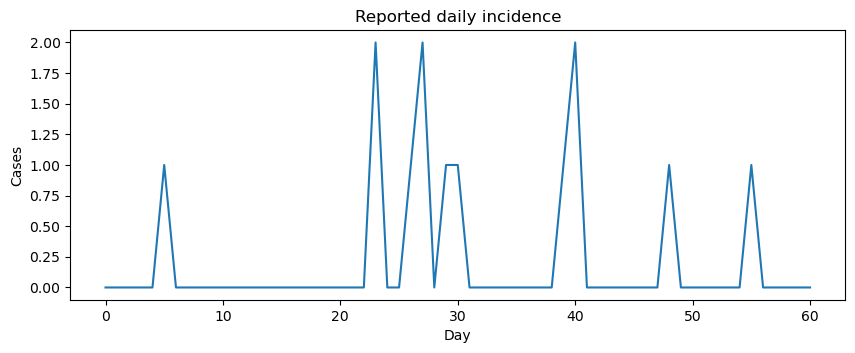

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(observed[:, 0])
ax.set_title("Reported daily incidence")
ax.set_xlabel("Day")
ax.set_ylabel("Cases")

In [10]:
from episbi.models.stochastic_se1e2e3ir import weekly_incidence

In [11]:
observed_weekly = weekly_incidence(observed)[:, None]

Text(0, 0.5, 'Cases')

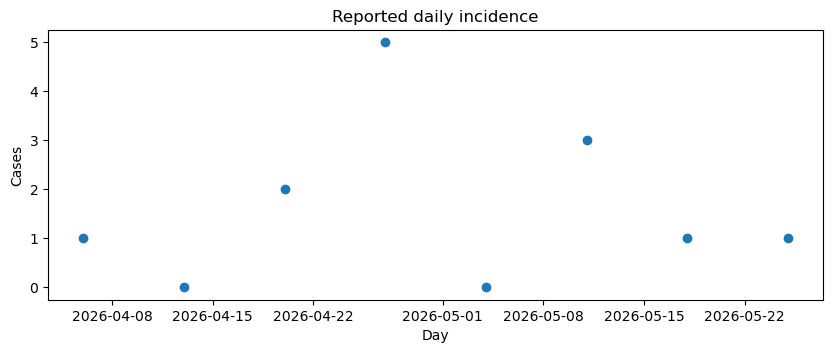

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.scatter(dates[5::7],observed_weekly[:, 0])
ax.set_title("Reported daily incidence")
ax.set_xlabel("Day")
ax.set_ylabel("Cases")

In [13]:
from joblib import Parallel, delayed

In [19]:
def sample_paper_prior(num_samples, seed=0):
    rng = np.random.default_rng(seed)

    r0 = rng.uniform(0.5, 3, size=num_samples)
    e1 = rng.integers(0, 2, size=num_samples)
    e3 = rng.integers(0, 3, size=num_samples)

    return np.column_stack([r0, e1, e3]).astype(np.float32)

In [34]:
def simulate_one(theta):
    r0, e1, e3 = theta

    sim = stochastic_se1e2e3ir({"R0": float(r0)},
        total_days=total_days,
        initial_e1=int(round(e1)),
        initial_e2=0,
        initial_e3=int(round(e3)),
        observation="weekly_incidence"
    )

    return sim["data"].astype(np.float32)

In [35]:
num_simulations = 100_000

In [36]:
rng = np.random.default_rng(0)
thetas = sample_paper_prior(num_simulations, seed=0)

In [37]:
xs = Parallel(n_jobs=-1, verbose=10)(
    delayed(simulate_one)(theta)
    for theta in thetas)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19214057191552236s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.16070914268493652s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 244 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done 320 tasks      | elap

In [40]:
xs =  np.stack(xs).astype(np.float32)

In [49]:
from sbi.utils import BoxUniform
import torch

In [51]:
support_prior = BoxUniform(
    low=torch.tensor([0.5, 0, 0], dtype=torch.float32),
    high=torch.tensor([3, 1.49, 2.49], dtype=torch.float32),
)

In [53]:
engine = SBIEngine(batch_size=256)
npe_result = engine.run_npe(
    obs_data=observed_weekly.squeeze(-1),
    prior=support_prior,
    thetas=thetas,
    xs=xs.squeeze(-1),
    input_dim=1,
    num_samples=1000,
    show_train_summary=False,
)

[*] Running NPE (use_lstm=False) with batch size 256...
 Neural network successfully converged after 54 epochs.

1086it [00:00, 30588.84it/s]            


In [54]:
_,samples = npe_result

In [55]:
posterior_samples = samples

param_df = pd.DataFrame(posterior_samples, columns=prior.names)
param_df.describe()

,R0,e1,e3
count,1000.000000,1000.000000,1000.000000
mean,1.415065,0.528883,1.622226
std,0.687695,0.457643,0.477048
min,0.613337,0.000076,0.042093
25%,0.764206,0.018919,1.310307
50%,1.254925,0.626760,1.673912
75%,1.958464,0.994955,1.977550
max,2.998949,1.045830,2.489084


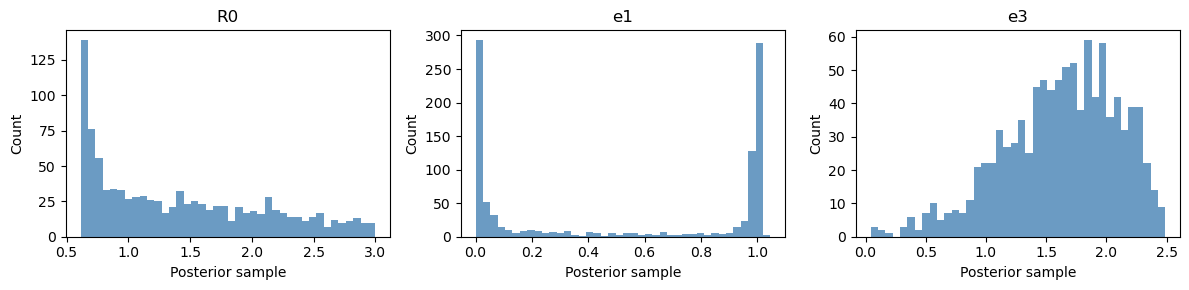

In [57]:
fig, axes = plt.subplots(1, len(prior.names), figsize=(4 * len(prior.names), 3))

if len(prior.names) == 1:
    axes = [axes]

for ax, name in zip(axes, prior.names):
    ax.hist(param_df[name], bins=40, color="steelblue", alpha=0.8)
    # ax.axvline(true_theta[name], color="black", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Posterior sample")
    ax.set_ylabel("Count")

fig.tight_layout()

In [15]:
npe_samples = pd.DataFrame(samples, columns = ['R0','e1','e3'])

In [16]:
npe_samples.mean()

R0    1.968981
e1    0.789640
e3    1.231683
dtype: float32

In [19]:
def summarize_samples(samples, names):
    if hasattr(samples, "detach"):
        samples = samples.detach().cpu().numpy()
    rows = []
    for i, name in enumerate(names):
        values = samples[:, i]
        rows.append(
            {
                "parameter": name,
                "mean": float(np.mean(values)),
                "median": float(np.median(values)),
                "q025": float(np.quantile(values, 0.025)),
                "q975": float(np.quantile(values, 0.975)),
            }
        )
    beta = samples[:, names.index("R0")]
    d_period = samples[:, names.index("D")]
    r0 = beta * d_period
    rows.append(
        {
            "parameter": "R0=beta*D",
            "mean": float(np.mean(r0)),
            "median": float(np.median(r0)),
            "q025": float(np.quantile(r0, 0.025)),
            "q975": float(np.quantile(r0, 0.975)),
        }
    )
    return pd.DataFrame(rows)

In [20]:
summary = summarize_samples(samples, prior.names)

ValueError: 'D' is not in list

In [21]:
summary

NameError: name 'summary' is not defined

In [22]:
sim = stochastic_se1e2e3ir(theta, total_days=total_days, population=population, initial_exposed=0 ,seed=seed + sim_id)

NameError: name 'stochastic_seird' is not defined

In [32]:
npe_samples

,beta,Z,D,delta
0,0.413461,9.838106,12.721887,0.378517
1,0.150814,7.803148,11.616617,0.386208
2,0.255844,9.593517,9.153756,0.363673
3,0.346339,10.345797,12.461679,0.322047
4,0.150680,10.473708,8.440070,0.379023
...,...,...,...,...
995,0.226578,6.066928,10.109184,0.441658
996,0.222894,6.000166,12.076406,0.423592
997,0.231356,8.388914,12.268062,0.374098
998,0.302424,11.830981,9.897305,0.377700


In [23]:
ppc_npe=[]
n_draws=1000

subset = npe_samples.sample(n=n_draws, random_state=0)
for _, row in subset.iterrows():
    simulation = stochastic_seird(row,  total_days=total_days, population=population, initial_exposed=0)
    ppc_npe.append(simulation)

NameError: name 'stochastic_seird' is not defined

In [36]:
from episbi.utils import plot_prediction_windows

In [39]:
# plot_prediction_windows(
#     y_obs=observed,
#     prediction=ppc_npe,
#     inference_days=total_days,
#     forecast_days=0,
# )

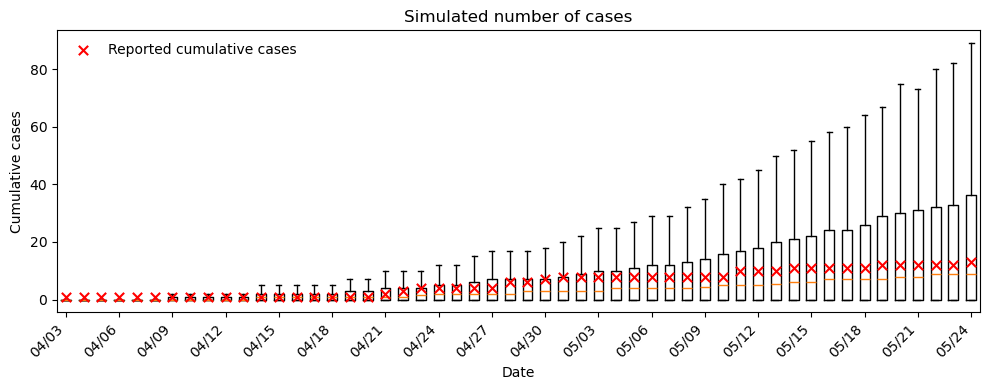

In [45]:
import matplotlib.pyplot as plt

initial_exposed = 0
initial_infectious = 1
n_draws = min(300, len(npe_samples))

subset = npe_samples.sample(n=n_draws, random_state=0)
sim_cases = []

for k, (_, row) in enumerate(subset.iterrows()):
    sim = stochastic_seird(
        row,
        total_days=total_days,
        population=population,
        initial_exposed=initial_exposed,
        initial_infectious=initial_infectious,
        seed=1000 + k,
        observation="cumulative_cases",
    )
    sim_cases.append(sim["data"][:, 0])

sim_cases = np.asarray(sim_cases)

dates = obs["Date"] if "Date" in obs.columns else np.arange(1, total_days + 1)
dates = pd.to_datetime(obs["Date"])
xlabels = dates.dt.strftime("%m/%d")
observed_cum = observed[:, 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(
    [sim_cases[:, t] for t in range(total_days)],
    positions=np.arange(total_days),
    widths=0.55,
    showfliers=False,
)
ax.scatter(
    np.arange(total_days),
    observed_cum,
    color="red",
    marker="x",
    s=45,
    label="Reported cumulative cases",
    zorder=3,
)

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative cases")
ax.set_title("Simulated number of cases")
ax.legend(frameon=False)
ax.set_xticks(np.arange(0, total_days, 3))
ax.set_xticklabels(np.asarray(xlabels)[::3], rotation=45, ha="right")
plt.tight_layout()
plt.show()